Starting to load S4.pkl... this may take 30-60 seconds because the file is huge!


C:\Users\gloriosog\AppData\Local\Temp\ipykernel_16592\1424530223.py:16: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding='latin1')


Successfully loaded data in 6.89 seconds!
Generating plot...


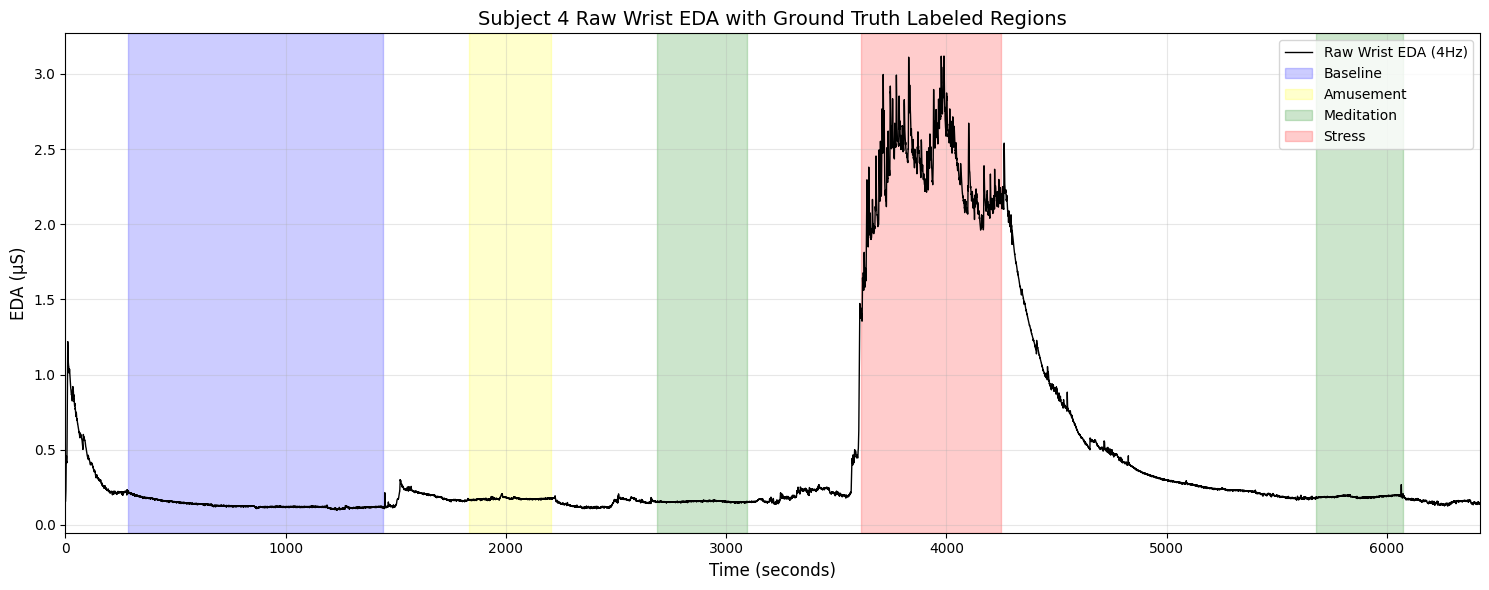

Done!


In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import time

# 1. Load Subject 4 data
wesad_path = r"C:\Users\gloriosog\OneDrive - Milwaukee School of Engineering\Year 4 Courses\Semester 1\Senior Design\WESAD Dataset\WESAD2\WESAD"
subject = "S4"
file_path = f"{wesad_path}\\{subject}\\{subject}.pkl"

print(f"Starting to load {subject}.pkl... this may take 30-60 seconds because the file is huge!")
start_time = time.time()

with open(file_path, 'rb') as f:
    # WESAD pickle files were generated in Python 2, so 'latin1' encoding is required
    data = pickle.load(f, encoding='latin1')

print(f"Successfully loaded data in {time.time() - start_time:.2f} seconds!")

# 2. Extract ONLY the wrist EDA signal and Labels
eda_raw = data['signal']['wrist']['EDA'].flatten()
fs_eda = 4 # Wrist EDA is sampled at 4Hz

# The labels are sampled at 700Hz
labels = data['label'].flatten()
fs_label = 700

# 3. Create time axes (in seconds)
time_eda = np.arange(len(eda_raw)) / fs_eda
time_label = np.arange(len(labels)) / fs_label

# 4. Plot raw EDA
print("Generating plot...")
plt.figure(figsize=(15, 6))
plt.plot(time_eda, eda_raw, label='Raw Wrist EDA (4Hz)', color='black', linewidth=1)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('EDA (μS)', fontsize=12)
plt.title('Subject 4 Raw Wrist EDA with Ground Truth Labeled Regions', fontsize=14)

# 5. Shade the regions based on the 700Hz label signal
colors = {1: 'blue', 2: 'red', 3: 'yellow', 4: 'green'}
labels_names = {1: 'Baseline', 2: 'Stress', 3: 'Amusement', 4: 'Meditation'}

# Find indices where the label changes to draw contiguous blocks
diff = np.diff(labels, prepend=-1)
change_indices = np.where(diff != 0)[0]
change_indices = np.append(change_indices, len(labels))

added_labels = set()
for i in range(len(change_indices) - 1):
    start_idx = change_indices[i]
    end_idx = change_indices[i+1]
    lbl = labels[start_idx]
    
    # We only care about providing colors for the main 4 states
    if lbl in colors:
        start_t = time_label[start_idx]
        end_t = time_label[end_idx-1]
        
        # Only add the label to the legend once
        lab_str = labels_names[lbl] if lbl not in added_labels else None
        plt.axvspan(start_t, end_t, color=colors[lbl], alpha=0.2, label=lab_str)
        added_labels.add(lbl)

plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, max(time_eda))
plt.tight_layout()
plt.show()
print("Done!")



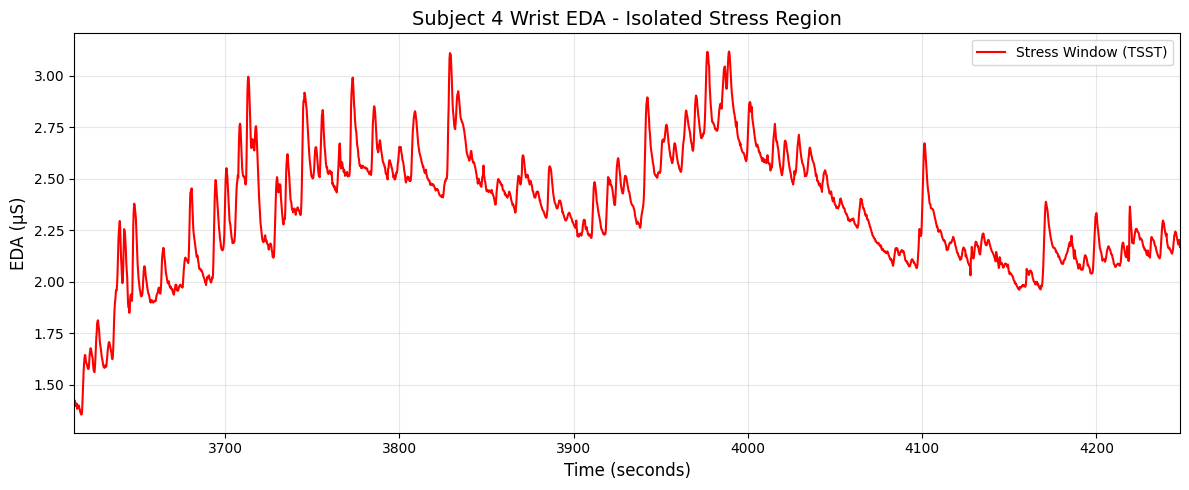

Isolated 2540 samples (10.58 minutes) of stress data.


In [2]:
# 1. Find the indices where the label is 2 (Stress) in the 700Hz label array
stress_indices_label = np.where(labels == 2)[0]

if len(stress_indices_label) > 0:
    # Get the start and end indices in the label array
    start_label_idx = stress_indices_label[0]
    end_label_idx = stress_indices_label[-1]
    
    # 2. Convert those indices to absolute time in seconds
    start_time_sec = start_label_idx / fs_label
    end_time_sec = end_label_idx / fs_label
    
    # 3. Convert absolute time into indices for the 4Hz EDA signal
    start_eda_idx = int(start_time_sec * fs_eda)
    end_eda_idx = int(end_time_sec * fs_eda)
    
    # 4. Slice out just the stress portion
    eda_stress = eda_raw[start_eda_idx:end_eda_idx]
    time_stress = time_eda[start_eda_idx:end_eda_idx] 
    # (Optional) If you want the plot to start at 0 seconds instead of absolute time:
    # time_stress = np.arange(len(eda_stress)) / fs_eda
    
    # 5. Plot the isolated stress EDA
    plt.figure(figsize=(12, 5))
    plt.plot(time_stress, eda_stress, label='Stress Window (TSST)', color='red', linewidth=1.5)
    plt.xlabel('Time (seconds)', fontsize=12)
    plt.ylabel('EDA (μS)', fontsize=12)
    plt.title('Subject 4 Wrist EDA - Isolated Stress Region', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xlim(time_stress[0], time_stress[-1])
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"Isolated {len(eda_stress)} samples ({len(eda_stress)/fs_eda / 60:.2f} minutes) of stress data.")
else:
    print("Could not find a stress region (label 2) in this dataset.")


Filtering complete. Running cvxEDA decomposition (this may take a moment)...
Decomposition complete! Plotting...


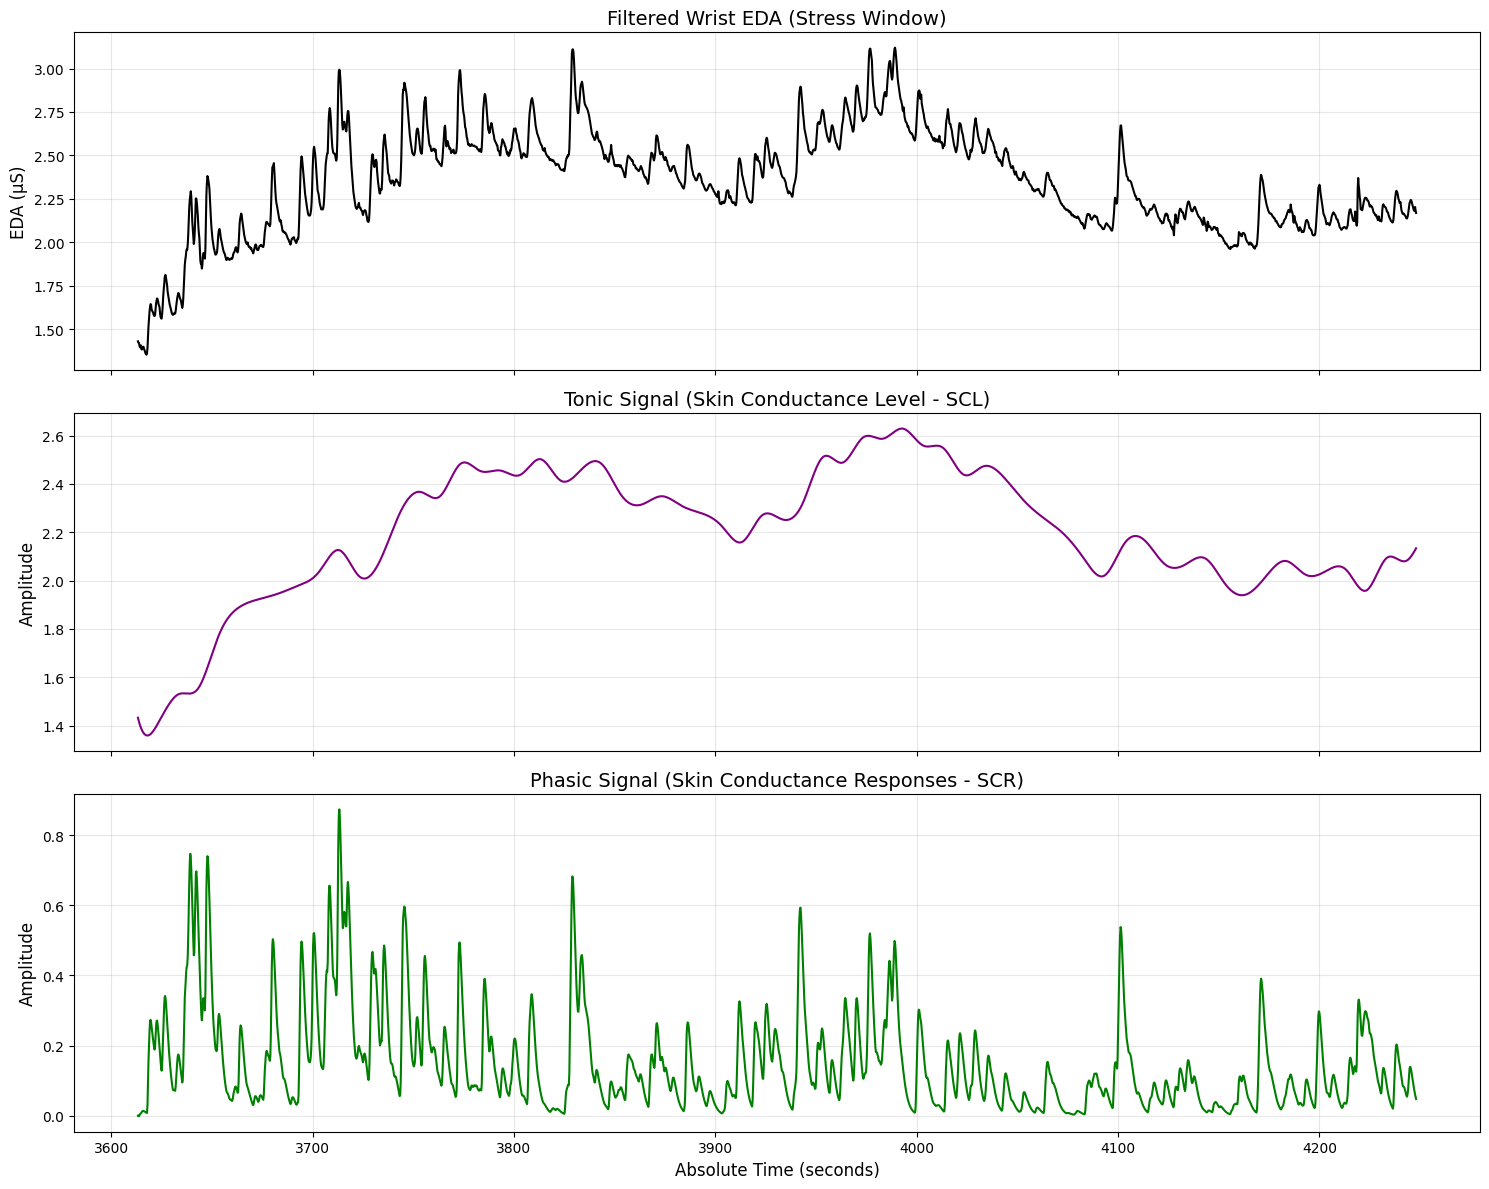

In [3]:
import neurokit2 as nk
from scipy import signal

# 1. Apply the low-pass Butterworth filter (matching [lowpass_filter](cci:1://file:///c:/Users/gloriosog/OneDrive%20-%20Milwaukee%20School%20of%20Engineering/Year%204%20Courses/Semester%201/Senior%20Design/Pipeline%20Rebuild/Grant%20old%20pipeline/extract_all_features.py:72:0-78:47) from the script)
# fs = 4, cutoff = 1.8 Hz, order = 4
cutoff = 1.8
nyquist = fs_eda / 2.0
if cutoff >= nyquist:
    cutoff = nyquist * 0.9

sos = signal.butter(4, cutoff, fs=fs_eda, btype='low', output='sos')
eda_stress_filtered = signal.sosfiltfilt(sos, eda_stress)

print("Filtering complete. Running cvxEDA decomposition (this may take a moment)...")

# 2. Extract Phasic and Tonic components using cvxEDA
eda_decomposed = nk.eda_phasic(eda_stress_filtered, sampling_rate=fs_eda, method='cvxeda')
eda_tonic = eda_decomposed['EDA_Tonic'].values
eda_phasic = eda_decomposed['EDA_Phasic'].values

print("Decomposition complete! Plotting...")

# 3. Plot the Filtered Raw, Tonic, and Phasic signals
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Plot 1: Filtered Raw EDA
ax1.plot(time_stress, eda_stress_filtered, color='black')
ax1.set_title("Filtered Wrist EDA (Stress Window)", fontsize=14)
ax1.set_ylabel("EDA (μS)", fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: Tonic Signal (Slow varying SCL)
ax2.plot(time_stress, eda_tonic, color='purple')
ax2.set_title("Tonic Signal (Skin Conductance Level - SCL)", fontsize=14)
ax2.set_ylabel("Amplitude", fontsize=12)
ax2.grid(True, alpha=0.3)

# Plot 3: Phasic Signal (Fast varying SCR)
ax3.plot(time_stress, eda_phasic, color='green')
ax3.set_title("Phasic Signal (Skin Conductance Responses - SCR)", fontsize=14)
ax3.set_ylabel("Amplitude", fontsize=12)
ax3.set_xlabel("Absolute Time (seconds)", fontsize=12)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Running causal decomposition...
Decomposition complete! Plotting...


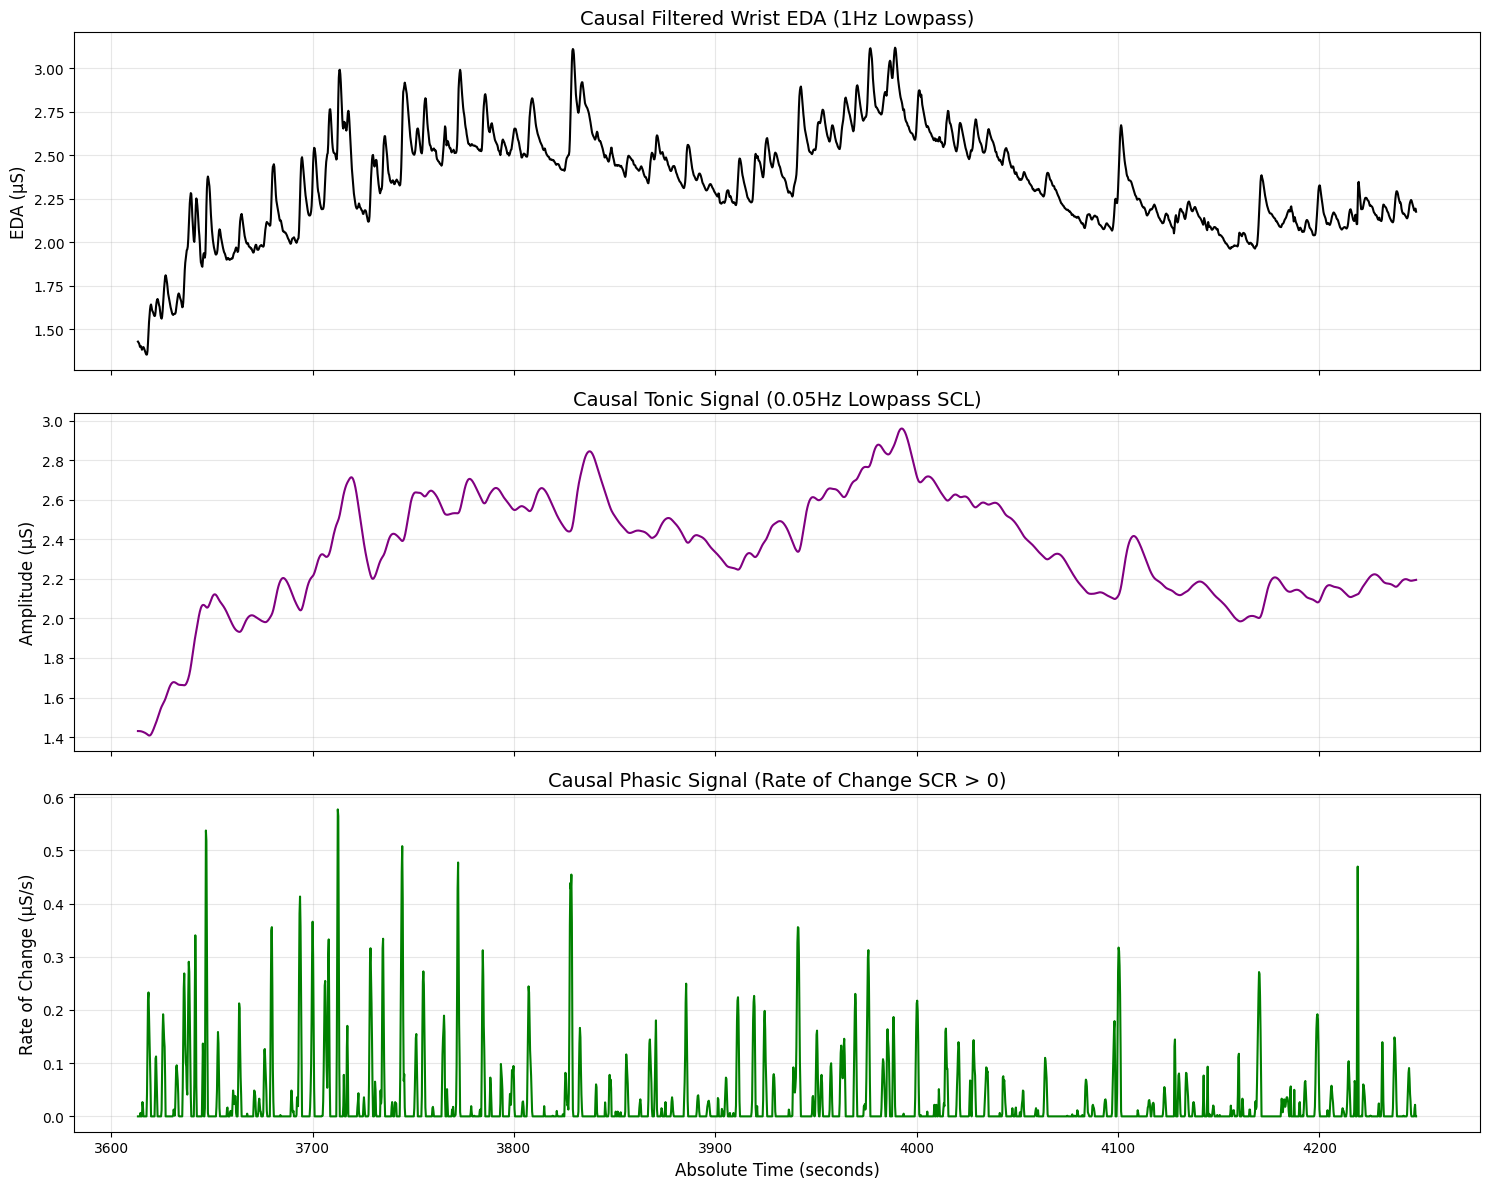

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, lfilter_zi

def extract_causal_eda(raw_eda, fs):
    """
    Decomposes a continuous Electrodermal Activity (EDA) signal into its 
    tonic and phasic components using strictly causal, computationally 
    lightweight filters.
    
    Args:
        raw_eda: A 1D numpy array of raw EDA data.
        fs: The sampling frequency in Hz.
        
    Returns:
        dict: Contains the 'smoothed', 'tonic', and 'phasic' 1D numpy arrays.
    """
    nyq = 0.5 * fs
    
    # ---------------------------------------------------------
    # Step 1: Artifact Smoothing (1.0 Hz Lowpass)
    # ---------------------------------------------------------
    b1, a1 = butter(1, 1.0 / nyq, btype='low')
    
    # Calculate the steady-state initial conditions for the filter
    # Scale it by the very FIRST value of our raw EDA array to remove transients
    zi1 = lfilter_zi(b1, a1) * raw_eda[0]
    
    # Pass the initial conditions into lfilter
    smoothed_eda, _ = lfilter(b1, a1, raw_eda, zi=zi1)
    
    # ---------------------------------------------------------
    # Step 2: Tonic Extraction (0.05 Hz Lowpass)
    # ---------------------------------------------------------
    b2, a2 = butter(2, 0.05 / nyq, btype='low')
    
    # Pre-load the state of this filter using the FIRST value of the SMOOTHED array
    zi2 = lfilter_zi(b2, a2) * smoothed_eda[0]
    
    # Filter the SMOOTHED signal
    tonic_causal, _ = lfilter(b2, a2, smoothed_eda, zi=zi2)
    
    # ---------------------------------------------------------
    # Step 3: Phasic Extraction (Rate of Change)
    # ---------------------------------------------------------
    dt = 1.0 / fs
    derivative = np.gradient(smoothed_eda, dt)
    phasic_causal = np.maximum(0, derivative)
    
    return {
        'smoothed': smoothed_eda,
        'tonic': tonic_causal,
        'phasic': phasic_causal
    }

# =====================================================================
# Apply to the isolated Stress Window and Plot
# =====================================================================

print("Running causal decomposition...")

# Run the extraction on the stress segment isolated earlier
causal_components = extract_causal_eda(eda_stress, fs_eda)

smoothed_stress = causal_components['smoothed']
tonic_stress = causal_components['tonic']
phasic_stress = causal_components['phasic']

print("Decomposition complete! Plotting...")

# Plot the Causal Smoothed Raw, Tonic, and Phasic signals
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Plot 1: Causal Smoothed EDA
ax1.plot(time_stress, smoothed_stress, color='black')
ax1.set_title("Causal Filtered Wrist EDA (1Hz Lowpass)", fontsize=14)
ax1.set_ylabel("EDA (μS)", fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: Causal Tonic Signal
ax2.plot(time_stress, tonic_stress, color='purple')
ax2.set_title("Causal Tonic Signal (0.05Hz Lowpass SCL)", fontsize=14)
ax2.set_ylabel("Amplitude (μS)", fontsize=12)
ax2.grid(True, alpha=0.3)

# Plot 3: Causal Phasic Signal (First Derivative)
ax3.plot(time_stress, phasic_stress, color='green')
ax3.set_title("Causal Phasic Signal (Rate of Change SCR > 0)", fontsize=14)
ax3.set_ylabel("Rate of Change (μS/s)", fontsize=12)
ax3.set_xlabel("Absolute Time (seconds)", fontsize=12)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


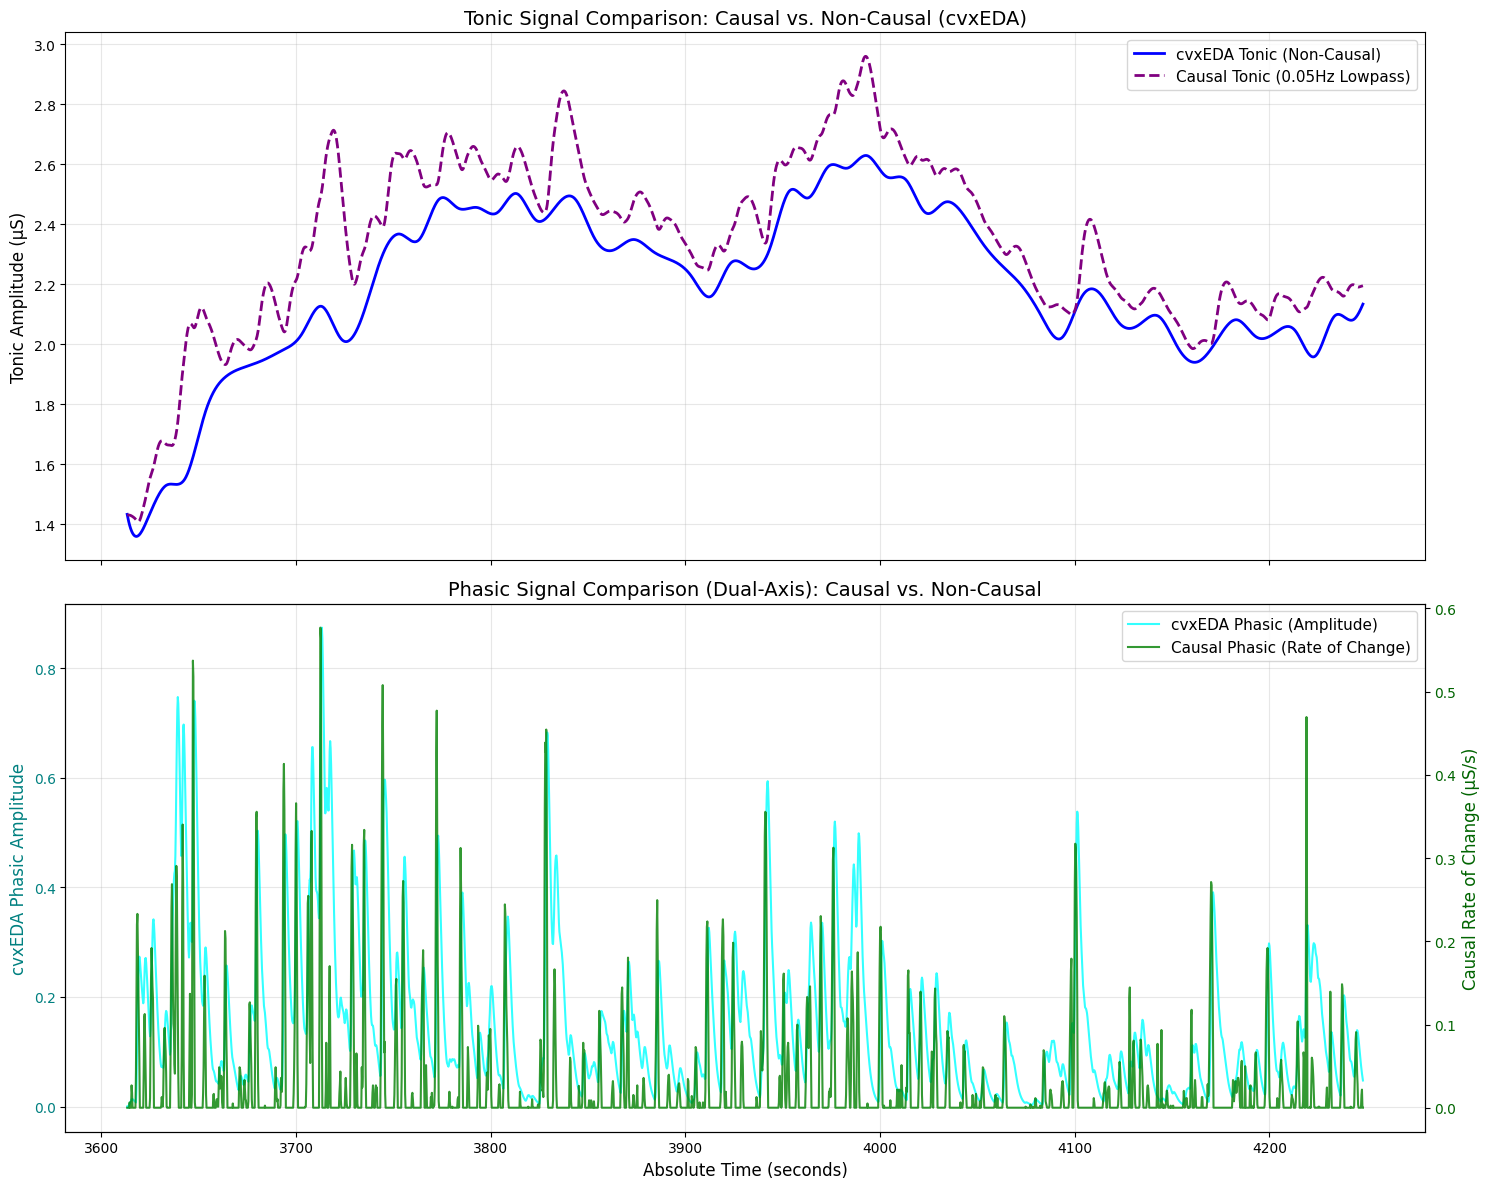

In [7]:
# Create a figure for the Overlaid Comparisons
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# =====================================================================
# 1. Tonic Comparison Overlay
# =====================================================================
ax1.plot(time_stress, eda_tonic, color='blue', label='cvxEDA Tonic (Non-Causal)', linewidth=2)
ax1.plot(time_stress, tonic_stress, color='purple', linestyle='--', label='Causal Tonic (0.05Hz Lowpass)', linewidth=2)

ax1.set_title("Tonic Signal Comparison: Causal vs. Non-Causal (cvxEDA)", fontsize=14)
ax1.set_ylabel("Tonic Amplitude (μS)", fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=11)

# =====================================================================
# 2. Phasic Comparison Overlay (Dual Y-Axis)
# =====================================================================
# Left Y-Axis for cvxEDA Phasic (Amplitude)
color1 = 'cyan'
ax2.plot(time_stress, eda_phasic, color=color1, label='cvxEDA Phasic (Amplitude)', linewidth=1.5, alpha=0.8)
ax2.set_ylabel("cvxEDA Phasic Amplitude", color='teal', fontsize=12)
ax2.tick_params(axis='y', labelcolor='teal')
ax2.set_title("Phasic Signal Comparison (Dual-Axis): Causal vs. Non-Causal", fontsize=14)
ax2.set_xlabel("Absolute Time (seconds)", fontsize=12)

# Right Y-Axis for Causal Phasic (Rate of Change)
ax2_twin = ax2.twinx()
color2 = 'green'
ax2_twin.plot(time_stress, phasic_stress, color=color2, label='Causal Phasic (Rate of Change)', linewidth=1.5, alpha=0.8)
ax2_twin.set_ylabel("Causal Rate of Change (μS/s)", color='darkgreen', fontsize=12)
ax2_twin.tick_params(axis='y', labelcolor='darkgreen')

ax2.grid(True, alpha=0.3)

# Combine legends for the dual-axis plot
lines_1, labels_1 = ax2.get_legend_handles_labels()
lines_2, labels_2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()


#### The causal tonic signal you plotted physically lags the real-time raw data by roughly 6.4 seconds.

A causal filter can only calculate the current value based on data it has already seen in the past. To heavily smooth out the fast phasic spikes and isolate the slow-moving tonic baseline (using a very low 0.05 Hz cutoff), the filter needs to look at several seconds of historical data. Because it's averaging past data to form the current point, the result naturally drags behind real time.

## Check Baseline Times for Each Subject

In [1]:
import pickle
import numpy as np
import time
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 1. Configuration
WESAD_PATH = Path(r"C:\Users\gloriosog\OneDrive - Milwaukee School of Engineering\Year 4 Courses\Semester 1\Senior Design\WESAD Dataset\WESAD2\WESAD")
SUBJECTS = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
FS_LABEL = 700

baseline_times = []

print("="*50)
print("Extracting Baseline Durations for WESAD Subjects")
print("="*50)

for subject in SUBJECTS:
    file_path = WESAD_PATH / subject / f"{subject}.pkl"
    
    print(f"Starting to load {subject}.pkl... this may take 30-60 seconds because the file is huge!")
    start_time = time.time()
    
    try:
        with open(file_path, 'rb') as f:
            # WESAD pickle files were generated in Python 2, so 'latin1' encoding is required
            data = pickle.load(f, encoding='latin1')
            
        print(f"Successfully loaded data in {time.time() - start_time:.2f} seconds!")
            
        # The labels are sampled at 700Hz
        labels = data['label'].flatten()
        
        # Calculate duration of label '1' (Baseline) in seconds
        baseline_samples = np.sum(labels == 1)
        baseline_duration_sec = baseline_samples / FS_LABEL
        baseline_duration_min = baseline_duration_sec / 60
        
        baseline_times.append({
            'subject': subject, 
            'minutes': baseline_duration_min,
            'seconds': baseline_duration_sec
        })
        
        print(f"-> {subject} Baseline Duration: {baseline_duration_min:.2f} minutes\n")
        
    except FileNotFoundError:
        print(f"[{subject}] Error: File not found at {file_path}\n")
    except Exception as e:
        print(f"[{subject}] Error processing file: {e}\n")

# Print the final compiled list
print("="*50)
print("FINAL STRATIFIED BASELINE DURATIONS")
print("="*50)
for result in baseline_times:
    print(f"Subject {result['subject']:<4}: {result['minutes']:.2f} minutes ({result['seconds']:.1f} seconds)")
print("="*50)


Extracting Baseline Durations for WESAD Subjects
Starting to load S2.pkl... this may take 30-60 seconds because the file is huge!
Successfully loaded data in 5.95 seconds!
-> S2 Baseline Duration: 19.07 minutes

Starting to load S3.pkl... this may take 30-60 seconds because the file is huge!
Successfully loaded data in 10.70 seconds!
-> S3 Baseline Duration: 19.00 minutes

Starting to load S4.pkl... this may take 30-60 seconds because the file is huge!
Successfully loaded data in 7.65 seconds!
-> S4 Baseline Duration: 19.30 minutes

Starting to load S5.pkl... this may take 30-60 seconds because the file is huge!
Successfully loaded data in 7.03 seconds!
-> S5 Baseline Duration: 19.97 minutes

Starting to load S6.pkl... this may take 30-60 seconds because the file is huge!
Successfully loaded data in 6.22 seconds!
-> S6 Baseline Duration: 19.67 minutes

Starting to load S7.pkl... this may take 30-60 seconds because the file is huge!
Successfully loaded data in 4.35 seconds!
-> S7 Baseli

In [ ]:
# ============================================================
# Cell 1 — Load EmotiBit EDA (Ice Test / Grant_data)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, lfilter_zi

# --- Paths ---
DATA_DIR = (
    r"C:\Users\gloriosog\OneDrive - Milwaukee School of Engineering"
    r"\Year 4 Courses\Semester 1\Senior Design\Senior Design Repo"
    r"\stress-detection-wearable\Ice_Test\Grant_data"
)
EA_FILE = DATA_DIR + r"\2026-04-21_11-32-56-286651_EA.csv"
TL_FILE = DATA_DIR + r"\2026-04-21_11-32-56-286651_TL.csv"

# --- Load EDA ---
# Columns: LocalTimestamp, EmotiBitTimestamp, PacketNumber, DataLength,
#          TypeTag, ProtocolVersion, DataReliability, EA
df_ea = pd.read_csv(EA_FILE)
print("EA columns:", df_ea.columns.tolist())
print(df_ea.head(3))

# LocalTimestamp is Unix epoch in SECONDS (magnitude ~1.7e9)
timestamps_s = df_ea["LocalTimestamp"].values        # seconds
eda_raw      = df_ea["EA"].values.astype(float)       # μS

# Relative time from first sample
t_rel = timestamps_s - timestamps_s[0]               # seconds from recording start

# Compute actual sample rate from data
fs_eda = len(t_rel) / (t_rel[-1] - t_rel[0])
print(f"\nRecording duration : {t_rel[-1]:.1f} s  ({t_rel[-1]/60:.2f} min)")
print(f"Total EDA samples  : {len(eda_raw)}")
print(f"Estimated fs_eda   : {fs_eda:.2f} Hz  (nominal 15 Hz)")

# --- Phase boundary variables (seconds from recording start) ---
t_cal_end    = 60    # end of Calibration
t_base_end   = 315   # end of Baseline  (5 min 15 s)
t_stress_end = 435   # end of Stress / CPT  (7 min 15 s)

print(f"\nPhase boundaries — cal_end={t_cal_end}s, base_end={t_base_end}s, stress_end={t_stress_end}s")

# --- Load TL (local timestamp map) for reference ---
df_tl = pd.read_csv(TL_FILE)
print("\nTL columns:", df_tl.columns.tolist())
print(df_tl.head(3))


In [ ]:
# ============================================================
# Cell 2 — Raw EDA Plot with Phase Labels
# ============================================================

fig, ax = plt.subplots(figsize=(15, 5))

# --- Raw EDA signal ---
ax.plot(t_rel, eda_raw, color='black', linewidth=0.8, label='Raw EDA')

# --- Phase shading (axvspan) ---
phase_spans = [
    (0,            t_cal_end,    'gray',  0.15, 'Calibration'),
    (t_cal_end,    t_base_end,   'blue',  0.15, 'Baseline'),
    (t_base_end,   t_stress_end, 'red',   0.15, 'Stress (CPT)'),
    (t_stress_end, t_rel[-1],    'green', 0.15, 'Recovery'),
]

for x0, x1, color, alpha, label in phase_spans:
    ax.axvspan(x0, x1, color=color, alpha=alpha, label=label)

# --- Vertical boundary lines ---
for xv, ls, lbl in [
    (t_cal_end,    '--', f'Cal end ({t_cal_end}s)'),
    (t_base_end,   '--', f'Baseline end ({t_base_end}s)'),
    (t_stress_end, '--', f'Stress end ({t_stress_end}s)'),
]:
    ax.axvline(xv, color='black', linestyle=ls, linewidth=1.2, alpha=0.7, label=lbl)

ax.set_xlim(0, t_rel[-1])
ax.set_xlabel('Time from recording start (s)', fontsize=12)
ax.set_ylabel('EDA (μS)', fontsize=12)
ax.set_title('Raw EDA — Full Recording with Phase Labels', fontsize=14)
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
